# 09_understand_panderm_mlp_probe_baseline3

This notebook is a **walk-through notebook** for **Baseline 3: Frozen PanDerm + MLP probe**.

It mirrors `scripts/eval_panderm_mlp_probe.py`, but the goal here is **understanding the full pipeline step by step**.

## What this notebook shows
1. How the official CSV is read and split into train / val / eval
2. How one image is loaded and transformed
3. How PanDerm Base is built and how the checkpoint is loaded
4. What tensor shapes look like during one forward pass
5. How frozen PanDerm embeddings are extracted
6. How optional feature normalization works
7. How the MLP head is built
8. What is actually learned in baseline 3
9. Where backpropagation happens in this baseline
10. How one eval image is classified
11. How final metrics are computed on the eval split


In [1]:
from pathlib import Path
import json
import random
import sys
import warnings
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings(
    'ignore',
    message=r'Importing from timm\.models\.layers is deprecated.*',
    category=FutureWarning,
)
warnings.filterwarnings(
    'ignore',
    message=r'Importing from timm\.models\.registry is deprecated.*',
    category=FutureWarning,
)
warnings.filterwarnings(
    'ignore',
    message=r'torch\.meshgrid: in an upcoming release.*',
    category=UserWarning,
)


## Config

Choose either HAM or BCN by changing `CSV_PATH`, `ROOT_PATH`, and `CLASS_NAMES_ARG`.

This notebook follows the same logic as `eval_panderm_mlp_probe.py`.

In [2]:
REPO_ROOT = Path('..').resolve()
PANDERM_CLASSIFICATION_DIR = (REPO_ROOT / 'external' / 'PanDerm' / 'classification').resolve()
if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

from models.builder import get_norm_constants  # type: ignore
from models.modeling_finetune import panderm_base_patch16_224_finetune  # type: ignore

CSV_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'HAM10000.csv'
ROOT_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'images'
CLASS_NAMES_ARG = 'akiec,bcc,bkl,df,mel,nv,vasc'

# CSV_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'bcn20000.csv'
# ROOT_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'images'
# CLASS_NAMES_ARG = 'actinic keratosis,basal cell carcinoma,melanoma,nevus,seborrheic keratosis,solar lentigo,squamous cell carcinoma,dermatofibroma,vascular lesion'

CHECKPOINT_PATH = REPO_ROOT / 'external' / 'weights' / 'panderm_bb_data6_checkpoint-499.pth'

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0
SEED = 42
VAL_SPLIT = 'val'
EVAL_SPLIT = 'test'

HIDDEN_DIM = 512
DROPOUT = 0.3
EPOCHS = 50
PATIENCE = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0

USE_BALANCED_SAMPLER = True
USE_CLASS_WEIGHTS = True
NORMALIZE_FEATURES = True

OUT_DIR = REPO_ROOT / 'outputs' / 'baseline3_understanding'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print('DEVICE:', DEVICE)
print('CSV_PATH exists:', CSV_PATH.exists(), CSV_PATH)
print('ROOT_PATH exists:', ROOT_PATH.exists(), ROOT_PATH)
print('CHECKPOINT_PATH exists:', CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)

DEVICE: mps
CSV_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv
ROOT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images
CHECKPOINT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('Seeded with:', SEED)

Seeded with: 42


## Load CSV and inspect splits

In [4]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())

split_series = df['split'].astype(str).str.lower()
train_df = df[split_series == 'train'].copy()
val_df = df[split_series == VAL_SPLIT].copy()
eval_df = df[split_series == EVAL_SPLIT].copy()

print('train_df:', train_df.shape)
print('val_df:', val_df.shape)
print('eval_df:', eval_df.shape)

print('\nTrain label counts:')
print(train_df['label'].value_counts().sort_index())
print('\nVal label counts:')
print(val_df['label'].value_counts().sort_index())
print('\nEval label counts:')
print(eval_df['label'].value_counts().sort_index())

Shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old


train_df: (8207, 13)
val_df: (575, 13)
eval_df: (1232, 13)

Train label counts:
label
0     273
1     448
2     941
3     102
4    1021
5    5304
6     118
Name: count, dtype: int64

Val label counts:
label
0     19
1     22
2     50
3      5
4     22
5    450
6      7
Name: count, dtype: int64

Eval label counts:
label
0     35
1     44
2    107
3      8
4     70
5    951
6     17
Name: count, dtype: int64


## Build class-name mapping

In [5]:
def make_class_name_map(y_train, y_val, y_eval, class_names_arg):
    all_ids = sorted(set(y_train.tolist()) | set(y_val.tolist()) | set(y_eval.tolist()))
    if class_names_arg is None:
        return {i: str(i) for i in all_ids}
    names = [x.strip() for x in class_names_arg.split(',')]
    mapping = {}
    for i in all_ids:
        mapping[i] = names[i] if i < len(names) else str(i)
    return mapping

CLASS_NAME_MAP = make_class_name_map(
    train_df['label'].astype(int).to_numpy(),
    val_df['label'].astype(int).to_numpy(),
    eval_df['label'].astype(int).to_numpy(),
    CLASS_NAMES_ARG,
)
display(pd.DataFrame({
    'class_id': list(CLASS_NAME_MAP.keys()),
    'class_name': list(CLASS_NAME_MAP.values()),
}))

,class_id,class_name
0,0,akiec
1,1,bcc
2,2,bkl
3,3,df
4,4,mel
5,5,nv
6,6,vasc


## One example image

lesion_id            HAM_0006071
image_id            ISIC_0032343
dx                           bkl
dx_type                    histo
age                         70.0
sex                       female
localization                face
dataset             vidir_modern
split                       test
label                          2
image           ISIC_0032343.jpg
binary_label                   0
age_group                    old
Name: 8783, dtype: object

Example path: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images/ISIC_0032343.jpg
Original PIL size: (600, 450)


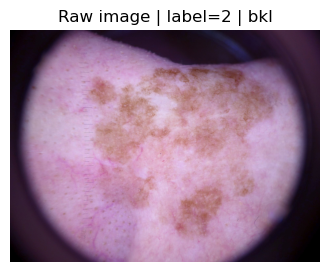

In [6]:
example_row = eval_df.iloc[0].copy()
example_path = ROOT_PATH / str(example_row['image'])
print(example_row)
print('\nExample path:', example_path)

with Image.open(example_path) as img:
    img_rgb = img.convert('RGB')
    print('Original PIL size:', img_rgb.size)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Raw image | label={example_row['label']} | {CLASS_NAME_MAP[int(example_row['label'])]}")
    plt.axis('off')
    plt.show()

## Transform used before the backbone

normalization method:  imagenet
Normalization mean: (0.485, 0.456, 0.406)
Normalization std: (0.228, 0.224, 0.225)
Transformed tensor shape: (3, 224, 224)
Tensor dtype: torch.float32
Tensor min/max: -1.8781511783599854 2.3088455200195312


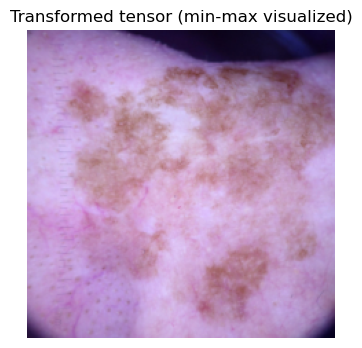

In [7]:
def build_eval_transform(image_size: int):
    mean, std = get_norm_constants('imagenet')
    print('Normalization mean:', mean)
    print('Normalization std:', std)
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

eval_transform = build_eval_transform(IMAGE_SIZE)
img_tensor = eval_transform(img_rgb)
print('Transformed tensor shape:', tuple(img_tensor.shape))
print('Tensor dtype:', img_tensor.dtype)
print('Tensor min/max:', float(img_tensor.min()), float(img_tensor.max()))

plt.figure(figsize=(4, 4))
vis = img_tensor.permute(1, 2, 0).cpu().numpy()
vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)
plt.imshow(vis)
plt.title('Transformed tensor (min-max visualized)')
plt.axis('off')
plt.show()

## Dataset and dataloader

In [8]:
def safe_open_image(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert('RGB')

class CSVImageDataset(Dataset):
    def __init__(self, df, root_path: Path, image_col='image', label_col='label', transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.root_path = root_path
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.root_path / str(row[self.image_col])
        img = safe_open_image(image_path)
        img = self.transform(img)
        label = int(row[self.label_col])
        meta = {'image': str(row[self.image_col]), 'label': label}
        return img, label, meta

train_ds = CSVImageDataset(train_df, ROOT_PATH, transform=eval_transform)
val_ds = CSVImageDataset(val_df, ROOT_PATH, transform=eval_transform)
eval_ds = CSVImageDataset(eval_df, ROOT_PATH, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

one_batch = next(iter(train_loader))
batch_images, batch_labels, batch_meta = one_batch
print('Batch image tensor shape:', tuple(batch_images.shape))
print('Batch labels shape:', tuple(batch_labels.shape))
print('First batch meta example:', {k: batch_meta[k][0] for k in batch_meta})

Batch image tensor shape: (64, 3, 224, 224)
Batch labels shape: (64,)
First batch meta example: {'image': 'ISIC_0027419.jpg', 'label': tensor(2)}


## Build the PanDerm backbone and load the checkpoint

Important: baseline 3 still uses a **frozen PanDerm backbone**. The backbone only produces embeddings. The trainable part is the small MLP classifier trained afterward.

In [9]:
def build_model(num_classes=1):
    model = panderm_base_patch16_224_finetune(
        pretrained=False,
        num_classes=num_classes,
        drop_rate=0.0,
        drop_path_rate=0.1,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=False,
        init_scale=0.001,
        use_rel_pos_bias=False,
        init_values=1e-5,
        lin_probe=False,
    )
    return model

def load_pretrained_backbone(model, checkpoint_path: Path):
    state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print('=' * 80)
    print('PanDerm checkpoint loading report')
    print('=' * 80)
    print('Missing keys:', len(missing))
    if missing:
        print('First missing keys:', missing[:20])
    print('Unexpected keys:', len(unexpected))
    if unexpected:
        print('First unexpected keys:', unexpected[:20])

backbone = build_model(num_classes=1)
load_pretrained_backbone(backbone, CHECKPOINT_PATH)
backbone = backbone.to(DEVICE)
backbone.eval()

print('\nModel class:', backbone.__class__.__name__)
print('Has forward_features:', hasattr(backbone, 'forward_features'))
print('Patch embed module:', type(backbone.patch_embed).__name__ if hasattr(backbone, 'patch_embed') else 'N/A')
print('Number of transformer blocks:', len(backbone.blocks) if hasattr(backbone, 'blocks') else 'N/A')
print('cls_token shape:', tuple(backbone.cls_token.shape) if hasattr(backbone, 'cls_token') else 'N/A')
print('pos_embed shape:', tuple(backbone.pos_embed.shape) if hasattr(backbone, 'pos_embed') else 'N/A')
print('head module:', backbone.head if hasattr(backbone, 'head') else 'N/A')

total_params = sum(p.numel() for p in backbone.parameters())
trainable_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}')
print(f'Trainable params flag-wise: {trainable_params:,}')
print('Important note: in baseline 3, these backbone weights are not updated because we only extract frozen features first.')

PanDerm checkpoint loading report
Missing keys: 2
First missing keys: ['head.weight', 'head.bias']
Unexpected keys: 0

Model class: VisionTransformer
Has forward_features: True
Patch embed module: PatchEmbed
Number of transformer blocks: 12
cls_token shape: (1, 1, 768)
pos_embed shape: (1, 197, 768)
head module: Linear(in_features=768, out_features=1, bias=True)
Total params: 85,808,641
Trainable params flag-wise: 85,657,345
Important note: in baseline 3, these backbone weights are not updated because we only extract frozen features first.


In [10]:
summary_rows = []
if hasattr(backbone, 'patch_embed'):
    summary_rows.append({'part': 'patch_embed', 'type': type(backbone.patch_embed).__name__})
summary_rows.append({'part': 'cls_token', 'type': str(tuple(backbone.cls_token.shape)) if hasattr(backbone, 'cls_token') else 'N/A'})
summary_rows.append({'part': 'pos_embed', 'type': str(tuple(backbone.pos_embed.shape)) if hasattr(backbone, 'pos_embed') else 'N/A'})
summary_rows.append({'part': 'transformer_blocks', 'type': len(backbone.blocks) if hasattr(backbone, 'blocks') else 'N/A'})
if hasattr(backbone, 'norm'):
    summary_rows.append({'part': 'norm', 'type': type(backbone.norm).__name__})
if hasattr(backbone, 'fc_norm'):
    summary_rows.append({'part': 'fc_norm', 'type': type(backbone.fc_norm).__name__})
summary_rows.append({'part': 'head', 'type': type(backbone.head).__name__ if hasattr(backbone, 'head') else 'N/A'})
display(pd.DataFrame(summary_rows))

,part,type
0,patch_embed,PatchEmbed
1,cls_token,"(1, 1, 768)"
2,pos_embed,"(1, 197, 768)"
3,transformer_blocks,12
4,norm,LayerNorm
5,fc_norm,NoneType
6,head,Linear


## Forward hooks for temporary shapes

This is only for inspection of the architecture.

In [11]:
shape_log = []
hooks = []

def register_shape_hook(module, name):
    def hook(module, inputs, output):
        in_shape = []
        for x in inputs:
            if torch.is_tensor(x):
                in_shape.append(tuple(x.shape))
            elif isinstance(x, (list, tuple)):
                in_shape.append(str(type(x)))
            else:
                in_shape.append(type(x).__name__)

        if torch.is_tensor(output):
            out_shape = tuple(output.shape)
        elif isinstance(output, tuple):
            out_shape = [tuple(o.shape) if torch.is_tensor(o) else type(o).__name__ for o in output]
        else:
            out_shape = type(output).__name__

        shape_log.append({'module': name, 'input_shape': in_shape, 'output_shape': out_shape})
    return module.register_forward_hook(hook)

if getattr(backbone, 'patch_embed', None) is not None:
    hooks.append(register_shape_hook(backbone.patch_embed, 'patch_embed'))
if getattr(backbone, 'blocks', None) is not None and len(backbone.blocks) > 0:
    hooks.append(register_shape_hook(backbone.blocks[0], 'block_0'))
    hooks.append(register_shape_hook(backbone.blocks[-1], 'block_last'))
if getattr(backbone, 'norm', None) is not None:
    hooks.append(register_shape_hook(backbone.norm, 'norm'))
if getattr(backbone, 'head', None) is not None:
    hooks.append(register_shape_hook(backbone.head, 'head'))

single_x = img_tensor.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    _ = backbone(single_x)

for h in hooks:
    h.remove()

display(pd.DataFrame(shape_log))

,module,input_shape,output_shape
0,patch_embed,"[(1, 3, 224, 224)]","(1, 196, 768)"
1,block_0,"[(1, 197, 768)]","(1, 197, 768)"
2,block_last,"[(1, 197, 768)]","(1, 197, 768)"
3,norm,"[(1, 197, 768)]","(1, 197, 768)"
4,head,"[(1, 768)]","(1, 1)"


## Important clarification: backbone architecture forward vs baseline-3 real learning path

The hook table includes the PanDerm head because `backbone(single_x)` runs the full network.

But baseline 3 does **not** use the PanDerm head as the trained decision rule.

The real baseline 3 pipeline is:
1. extract frozen PanDerm embeddings
2. optionally standardize embeddings
3. train a separate small MLP on those embeddings
4. use val split for model selection / early stopping
5. evaluate best MLP on test embeddings


In [12]:
with torch.no_grad():
    feats_direct = backbone.forward_features(single_x)
    logits_direct = backbone(single_x)

print('Output of backbone.forward_features(single_x):')
print('  shape:', tuple(feats_direct.shape) if torch.is_tensor(feats_direct) else type(feats_direct).__name__)
print('\nOutput of backbone(single_x):')
print('  shape:', tuple(logits_direct.shape) if torch.is_tensor(logits_direct) else type(logits_direct).__name__)

print('\nInterpretation:')
print('- Baseline 3 uses the embedding from forward_features().')
print('- The learned classifier is a separate MLP trained afterward.')
print('- So the PanDerm head is not the learned decision rule in baseline 3.')

Output of backbone.forward_features(single_x):
  shape: (1, 768)

Output of backbone(single_x):
  shape: (1, 1)

Interpretation:
- Baseline 3 uses the embedding from forward_features().
- The learned classifier is a separate MLP trained afterward.
- So the PanDerm head is not the learned decision rule in baseline 3.


## Feature extraction logic
This mirrors the script exactly.

In [13]:
@torch.no_grad()
def extract_features_debug(model, images: torch.Tensor):
    debug = {}

    if hasattr(model, 'forward_features'):
        feats = model.forward_features(images)
        debug['used_forward_features'] = True
    else:
        feats = model(images)
        debug['used_forward_features'] = False

    debug['raw_output_type'] = type(feats).__name__
    if torch.is_tensor(feats):
        debug['raw_output_shape'] = tuple(feats.shape)
    elif isinstance(feats, tuple):
        debug['raw_output_shape'] = [tuple(x.shape) if torch.is_tensor(x) else type(x).__name__ for x in feats]

    if isinstance(feats, tuple):
        feats = feats[0]
        debug['tuple_reduced_to_first'] = True
    else:
        debug['tuple_reduced_to_first'] = False

    if feats.ndim == 3:
        debug['token_sequence_shape'] = tuple(feats.shape)
        if feats.shape[1] > 1:
            feats = feats[:, 0]
            debug['cls_taken'] = True
            debug['after_cls_shape'] = tuple(feats.shape)
        else:
            feats = feats.mean(dim=1)
            debug['mean_pooled_single_token_sequence'] = True

    if feats.ndim > 2:
        feats = feats.flatten(start_dim=1)
        debug['flattened'] = True
        debug['after_flatten_shape'] = tuple(feats.shape)
    else:
        debug['flattened'] = False

    feats_before_norm = feats.clone()
    feats = F.normalize(feats, dim=1)
    debug['final_feature_shape'] = tuple(feats.shape)
    debug['norm_before'] = torch.norm(feats_before_norm, dim=1).cpu().numpy().tolist()
    debug['norm_after'] = torch.norm(feats, dim=1).cpu().numpy().tolist()
    return feats, debug

single_feat, single_debug = extract_features_debug(backbone, single_x)
print(json.dumps(single_debug, indent=2))

{
  "used_forward_features": true,
  "raw_output_type": "Tensor",
  "raw_output_shape": [
    1,
    768
  ],
  "tuple_reduced_to_first": false,
  "flattened": false,
  "final_feature_shape": [
    1,
    768
  ],
  "norm_before": [
    15.424509048461914
  ],
  "norm_after": [
    0.9999999403953552
  ]
}


## Collect train / val / eval features

In [14]:
@torch.no_grad()
def collect_features(model, loader, device):
    model.eval()
    all_feats = []
    all_labels = []
    all_meta = []

    for images, labels, meta in tqdm(loader, desc='extract_features', leave=False):
        images = images.to(device, non_blocking=(device == 'cuda'))
        feats, _ = extract_features_debug(model, images)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
        all_meta.extend([{k: meta[k][i] for k in meta} for i in range(len(labels))])

    feats_np = np.concatenate(all_feats, axis=0)
    labels_np = np.concatenate(all_labels, axis=0)
    return feats_np, labels_np, all_meta

train_feats, train_labels, train_meta = collect_features(backbone, train_loader, DEVICE)
val_feats, val_labels, val_meta = collect_features(backbone, val_loader, DEVICE)
eval_feats, eval_labels, eval_meta = collect_features(backbone, eval_loader, DEVICE)

print('train_feats shape:', train_feats.shape)
print('val_feats shape:', val_feats.shape)
print('eval_feats shape:', eval_feats.shape)
print('Feature dimension:', train_feats.shape[1])

extract_features:   0%|          | 0/129 [00:00<?, ?it/s]

extract_features:   0%|          | 0/9 [00:00<?, ?it/s]

extract_features:   0%|          | 0/20 [00:00<?, ?it/s]

train_feats shape: (8207, 768)
val_feats shape: (575, 768)
eval_feats shape: (1232, 768)
Feature dimension: 768


## Optional feature normalization

If enabled, this is done **after frozen PanDerm feature extraction** and **before MLP training**.

In [15]:
scaler = None
if NORMALIZE_FEATURES:
    scaler = StandardScaler()
    train_feats = scaler.fit_transform(train_feats)
    val_feats = scaler.transform(val_feats)
    eval_feats = scaler.transform(eval_feats)
    print('Feature normalization applied with StandardScaler.')
    print('Scaler mean shape:', scaler.mean_.shape)
    print('Scaler scale shape:', scaler.scale_.shape)
else:
    print('Feature normalization disabled.')

Feature normalization applied with StandardScaler.
Scaler mean shape: (768,)
Scaler scale shape: (768,)


## MLP head used in baseline 3

This is the trainable classifier used on top of frozen embeddings.

In [16]:
class MLPHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, num_classes: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

num_classes = int(max(train_labels.max(), val_labels.max(), eval_labels.max()) + 1)
mlp_model = MLPHead(
    in_dim=train_feats.shape[1],
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
    dropout=DROPOUT,
).to(DEVICE)

print(mlp_model)
print('Trainable MLP params:', sum(p.numel() for p in mlp_model.parameters() if p.requires_grad))

MLPHead(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=7, bias=True)
  )
)
Trainable MLP params: 397319


## What is learned in baseline 3?

Key idea:
- **PanDerm backbone:** frozen
- **MLP head:** trainable
- **Backpropagation happens only through the MLP head**, because the backbone embeddings were extracted first and stored

So compared to baseline 2:
- baseline 2 learns a linear classifier
- baseline 3 learns a small nonlinear classifier

In [17]:
print('Is PanDerm backbone updated during baseline 3? -> No')
print('Is there backpropagation somewhere in baseline 3? -> Yes')
print('Where does backprop happen? -> Inside the MLP head training step')
print('What receives gradients? -> The MLP parameters')
print('What does NOT receive gradients in this setup? -> The frozen PanDerm backbone')

Is PanDerm backbone updated during baseline 3? -> No
Is there backpropagation somewhere in baseline 3? -> Yes
Where does backprop happen? -> Inside the MLP head training step
What receives gradients? -> The MLP parameters
What does NOT receive gradients in this setup? -> The frozen PanDerm backbone


## Important implementation detail: why the backbone gets no gradients

In this implementation, the PanDerm backbone is first used to extract and store train / val / eval embeddings.

After that, the MLP is trained only on those stored embeddings.

So during MLP training:
- the backbone is not called again
- the computation graph starts at the embedding tensor
- gradients flow only through the MLP head

## Build embedding loaders for MLP training

In [18]:
def make_embedding_loader(feats, labels, batch_size, shuffle, device, use_balanced_sampler=False):
    x = torch.tensor(feats, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)
    ds = TensorDataset(x, y)

    if use_balanced_sampler:
        class_counts = np.bincount(labels)
        class_weights = np.zeros_like(class_counts, dtype=np.float64)
        nonzero = class_counts > 0
        class_weights[nonzero] = 1.0 / class_counts[nonzero]
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=False, sampler=sampler, pin_memory=(device == 'cuda'))

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=(device == 'cuda'))

train_emb_loader = make_embedding_loader(
    train_feats, train_labels, BATCH_SIZE, shuffle=not USE_BALANCED_SAMPLER,
    device=DEVICE, use_balanced_sampler=USE_BALANCED_SAMPLER,
)
val_emb_loader = make_embedding_loader(
    val_feats, val_labels, BATCH_SIZE, shuffle=False,
    device=DEVICE, use_balanced_sampler=False,
)

xb_demo, yb_demo = next(iter(train_emb_loader))
print('Embedding batch shape:', tuple(xb_demo.shape))
print('Embedding label batch shape:', tuple(yb_demo.shape))

Embedding batch shape: (64, 768)
Embedding label batch shape: (64,)


## One explicit forward pass through the MLP head

In [19]:
x_demo = xb_demo[:1].to(DEVICE)
with torch.no_grad():
    logits_demo = mlp_model(x_demo)
    probs_demo = torch.softmax(logits_demo, dim=1)

print('Single embedding shape into MLP:', tuple(x_demo.shape))
print('MLP logits shape:', tuple(logits_demo.shape))
print('MLP probability shape:', tuple(probs_demo.shape))

Single embedding shape into MLP: (1, 768)
MLP logits shape: (1, 7)
MLP probability shape: (1, 7)


## Loss, class weights, and optimizer

In [20]:
class_weights_tensor = None
if USE_CLASS_WEIGHTS:
    class_counts = np.bincount(train_labels, minlength=num_classes).astype(np.float64)
    weights = np.zeros(num_classes, dtype=np.float32)
    nz = class_counts > 0
    weights[nz] = class_counts.sum() / (num_classes * class_counts[nz])
    class_weights_tensor = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print('Using class weights:', weights)
else:
    print('Class weights disabled.')

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print('Criterion:', criterion)
print('Optimizer:', optimizer.__class__.__name__)

Using class weights: [ 4.29461    2.617028   1.245939  11.494398   1.148314   0.2210461
  9.935835 ]
Criterion: CrossEntropyLoss()
Optimizer: AdamW


## Show one real backward pass

This is the key difference from baselines 1 and 2.

Here we explicitly show:
- logits
- loss
- backward pass
- gradients on MLP parameters

But note: the backbone is not part of this computation graph anymore, because we already extracted features beforehand.

In [21]:
mlp_model.zero_grad()

xb_small = xb_demo[:8].to(DEVICE)
yb_small = yb_demo[:8].to(DEVICE)

logits_small = mlp_model(xb_small)
loss_small = criterion(logits_small, yb_small)

print('xb_small shape:', tuple(xb_small.shape))
print('yb_small shape:', tuple(yb_small.shape))
print('logits_small shape:', tuple(logits_small.shape))
print('loss value:', float(loss_small.item()))

loss_small.backward()

for name, param in mlp_model.named_parameters():
    if param.grad is not None:
        print(f'{name}: grad shape={tuple(param.grad.shape)}, grad_norm={float(param.grad.norm().item()):.6f}')
    else:
        print(f'{name}: grad=None')

print('\nInterpretation:')
print('- This backward pass updates only the MLP parameters.')
print('- The PanDerm backbone does not get gradients here because embeddings were precomputed.')

xb_small shape: (8, 768)
yb_small shape: (8,)
logits_small shape: (8, 7)
loss value: 1.9607800245285034
net.0.weight: grad shape=(512, 768), grad_norm=6.560602
net.0.bias: grad shape=(512,), grad_norm=0.207484
net.3.weight: grad shape=(7, 512), grad_norm=4.509593
net.3.bias: grad shape=(7,), grad_norm=0.504150

Interpretation:
- This backward pass updates only the MLP parameters.
- The PanDerm backbone does not get gradients here because embeddings were precomputed.


## Training loop for the MLP probe

This mirrors the script logic with:
- train split for learning
- val split for model selection
- early stopping based on val balanced accuracy

In [22]:
def fit_mlp_probe(
    train_feats,
    train_labels,
    val_feats,
    val_labels,
    num_classes,
    device,
    hidden_dim,
    dropout,
    epochs,
    patience,
    lr,
    weight_decay,
    label_smoothing,
    batch_size,
    use_balanced_sampler,
    use_class_weights,
    seed,
):
    torch.manual_seed(seed)

    train_loader = make_embedding_loader(
        train_feats,
        train_labels,
        batch_size=batch_size,
        shuffle=not use_balanced_sampler,
        device=device,
        use_balanced_sampler=use_balanced_sampler,
    )
    val_loader = make_embedding_loader(
        val_feats,
        val_labels,
        batch_size=batch_size,
        shuffle=False,
        device=device,
        use_balanced_sampler=False,
    )

    model = MLPHead(
        in_dim=train_feats.shape[1],
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        dropout=dropout,
    ).to(device)

    class_weights_tensor = None
    if use_class_weights:
        class_counts = np.bincount(train_labels, minlength=num_classes).astype(np.float64)
        weights = np.zeros(num_classes, dtype=np.float32)
        nz = class_counts > 0
        weights[nz] = class_counts.sum() / (num_classes * class_counts[nz])
        class_weights_tensor = torch.tensor(weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_epoch = -1
    best_score = -np.inf
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=(device == 'cuda'))
            yb = yb.to(device, non_blocking=(device == 'cuda'))

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(float(loss.item()))

        model.eval()
        val_logits_all = []
        val_y_all = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=(device == 'cuda'))
                logits = model(xb)
                val_logits_all.append(logits.cpu())
                val_y_all.append(yb)

        val_logits = torch.cat(val_logits_all, dim=0)
        val_y = torch.cat(val_y_all, dim=0).numpy()
        val_pred = val_logits.argmax(dim=1).numpy()

        val_bal_acc = balanced_accuracy_score(val_y, val_pred)
        val_macro_f1 = f1_score(val_y, val_pred, average='macro', zero_division=0)
        val_mcc = matthews_corrcoef(val_y, val_pred)

        history.append({
            'epoch': epoch,
            'train_loss': float(np.mean(train_losses)) if train_losses else None,
            'val_balanced_accuracy': float(val_bal_acc),
            'val_macro_f1': float(val_macro_f1),
            'val_mcc': float(val_mcc),
        })

        print(
            f'[mlp_probe] Epoch {epoch:02d}/{epochs} | '
            f'train_loss={np.mean(train_losses):.4f} | '
            f'val_bal_acc={val_bal_acc:.4f} | '
            f'val_macro_f1={val_macro_f1:.4f} | '
            f'val_mcc={val_mcc:.4f}'
        )

        if val_bal_acc > best_score:
            best_score = val_bal_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f'[mlp_probe] Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(best_state)
    training_summary = {
        'best_epoch': int(best_epoch),
        'best_val_balanced_accuracy': float(best_score),
        'history': history,
    }
    return model, training_summary

trained_mlp, training_summary = fit_mlp_probe(
    train_feats=train_feats,
    train_labels=train_labels,
    val_feats=val_feats,
    val_labels=val_labels,
    num_classes=num_classes,
    device=DEVICE,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    patience=PATIENCE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    label_smoothing=LABEL_SMOOTHING,
    batch_size=BATCH_SIZE,
    use_balanced_sampler=USE_BALANCED_SAMPLER,
    use_class_weights=USE_CLASS_WEIGHTS,
    seed=SEED,
)

print('\nTraining summary:')
print(json.dumps({
    'best_epoch': training_summary['best_epoch'],
    'best_val_balanced_accuracy': training_summary['best_val_balanced_accuracy'],
}, indent=2))

[mlp_probe] Epoch 01/50 | train_loss=0.3879 | val_bal_acc=0.7388 | val_macro_f1=0.4477 | val_mcc=0.4411
[mlp_probe] Epoch 02/50 | train_loss=0.1400 | val_bal_acc=0.7849 | val_macro_f1=0.5777 | val_mcc=0.5582
[mlp_probe] Epoch 03/50 | train_loss=0.0986 | val_bal_acc=0.7904 | val_macro_f1=0.5920 | val_mcc=0.5684
[mlp_probe] Epoch 04/50 | train_loss=0.0724 | val_bal_acc=0.7690 | val_macro_f1=0.6017 | val_mcc=0.5911
[mlp_probe] Epoch 05/50 | train_loss=0.0720 | val_bal_acc=0.7805 | val_macro_f1=0.6225 | val_mcc=0.6235
[mlp_probe] Epoch 06/50 | train_loss=0.0593 | val_bal_acc=0.7751 | val_macro_f1=0.6718 | val_mcc=0.6320
[mlp_probe] Epoch 07/50 | train_loss=0.0450 | val_bal_acc=0.8192 | val_macro_f1=0.7143 | val_mcc=0.6910
[mlp_probe] Epoch 08/50 | train_loss=0.0317 | val_bal_acc=0.7471 | val_macro_f1=0.6520 | val_mcc=0.6546
[mlp_probe] Epoch 09/50 | train_loss=0.0342 | val_bal_acc=0.7566 | val_macro_f1=0.6663 | val_mcc=0.6725
[mlp_probe] Epoch 10/50 | train_loss=0.0350 | val_bal_acc=0.7734

In [31]:
print('Best model selection is based on val balanced accuracy.')
print('After training, the MLP weights are restored to the best val epoch.')

Best model selection is based on val balanced accuracy.
After training, the MLP weights are restored to the best val epoch.


## Plot validation history

,epoch,train_loss,val_balanced_accuracy,val_macro_f1,val_mcc
0,1,0.387888,0.738829,0.447703,0.441100
1,2,0.139986,0.784932,0.577719,0.558201
2,3,0.098553,0.790373,0.592044,0.568379
3,4,0.072365,0.768968,0.601718,0.591110
4,5,0.071972,0.780500,0.622518,0.623531


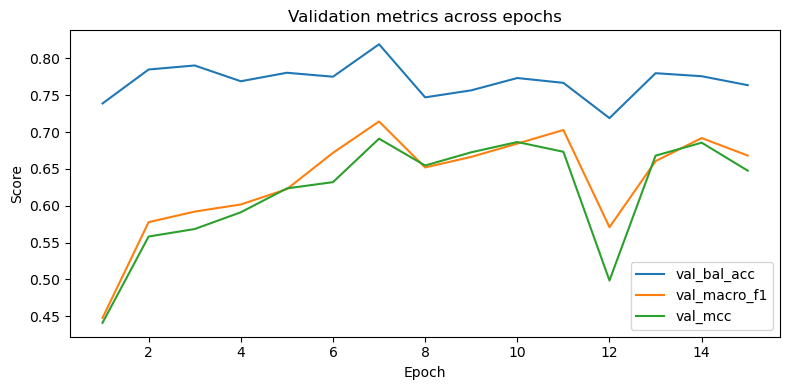

In [23]:
hist_df = pd.DataFrame(training_summary['history'])
display(hist_df.head())

plt.figure(figsize=(8, 4))
plt.plot(hist_df['epoch'], hist_df['val_balanced_accuracy'], label='val_bal_acc')
plt.plot(hist_df['epoch'], hist_df['val_macro_f1'], label='val_macro_f1')
plt.plot(hist_df['epoch'], hist_df['val_mcc'], label='val_mcc')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation metrics across epochs')
plt.legend()
plt.tight_layout()
plt.show()

## Predict on one example embedding in detail

In [24]:
@torch.no_grad()
def predict_mlp(model, feats, batch_size, device):
    loader = DataLoader(
        TensorDataset(torch.tensor(feats, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
        pin_memory=(device == 'cuda'),
    )

    model.eval()
    logits_all = []
    for (xb,) in loader:
        xb = xb.to(device, non_blocking=(device == 'cuda'))
        logits = model(xb)
        logits_all.append(logits.cpu())

    logits = torch.cat(logits_all, dim=0)
    probs = torch.softmax(logits, dim=1).numpy()
    preds = logits.argmax(dim=1).numpy()
    return preds, probs, logits.numpy()

example_eval_idx = 0
x_raw = eval_feats[example_eval_idx:example_eval_idx+1]
pred_one, probs_one, logits_one = predict_mlp(trained_mlp, x_raw, batch_size=1, device=DEVICE)

print('Example meta:', eval_meta[example_eval_idx])
print('Input embedding shape to trained MLP:', x_raw.shape)
print('MLP logits shape:', logits_one.shape)
print('Probability shape:', probs_one.shape)
print('Predicted class id:', int(pred_one[0]))
print('Predicted class name:', CLASS_NAME_MAP[int(pred_one[0])])

Example meta: {'image': 'ISIC_0032343.jpg', 'label': tensor(2)}
Input embedding shape to trained MLP: (1, 768)
MLP logits shape: (1, 7)
Probability shape: (1, 7)
Predicted class id: 2
Predicted class name: bkl


,class_id,class_name,probability
0,2,bkl,9.992767e-01
1,4,mel,5.749952e-04
2,5,nv,1.181424e-04
3,0,akiec,2.935672e-05
4,3,df,8.373796e-07
5,1,bcc,4.780619e-09
6,6,vasc,8.209604e-10


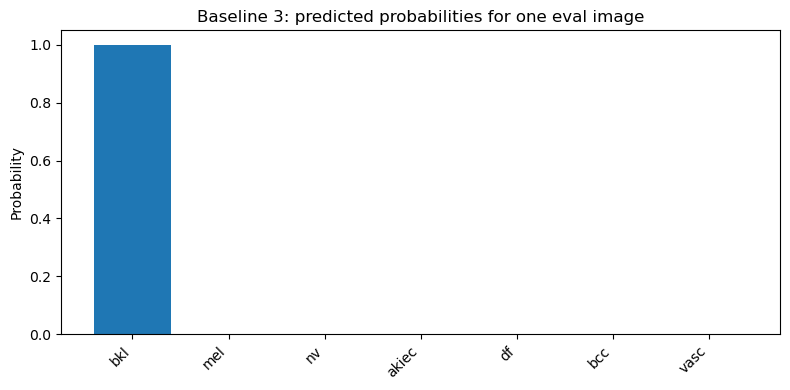

In [25]:
detail_df = pd.DataFrame({
    'class_id': list(range(num_classes)),
    'class_name': [CLASS_NAME_MAP[i] for i in range(num_classes)],
    'probability': probs_one[0],
})
detail_df = detail_df.sort_values('probability', ascending=False).reset_index(drop=True)
display(detail_df)

plt.figure(figsize=(8, 4))
plt.bar(detail_df['class_name'], detail_df['probability'])
plt.xticks(rotation=45, ha='right')
plt.title('Baseline 3: predicted probabilities for one eval image')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

## Full eval prediction

In [26]:
preds, pred_probs, pred_logits = predict_mlp(
    trained_mlp,
    eval_feats,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)
y_true = eval_labels

## Metrics

In [27]:
def compute_metrics(y_true, y_pred, class_name_map):
    label_ids = sorted(class_name_map.keys())
    target_names = [class_name_map[i] for i in label_ids]

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    per_class_recall_values = recall_score(
        y_true,
        y_pred,
        labels=label_ids,
        average=None,
        zero_division=0,
    )

    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'mcc': float(matthews_corrcoef(y_true, y_pred)),
        'per_class_recall': {
            class_name_map[label_id]: float(per_class_recall_values[idx])
            for idx, label_id in enumerate(label_ids)
        },
        'confusion_matrix': cm.tolist(),
        'classification_report': classification_report(
            y_true,
            y_pred,
            labels=label_ids,
            target_names=target_names,
            output_dict=True,
            zero_division=0,
        ),
    }

metrics = compute_metrics(y_true, preds, CLASS_NAME_MAP)
metrics['best_epoch'] = training_summary['best_epoch']
metrics['best_val_balanced_accuracy'] = training_summary['best_val_balanced_accuracy']

print(json.dumps({
    'accuracy': metrics['accuracy'],
    'balanced_accuracy': metrics['balanced_accuracy'],
    'macro_f1': metrics['macro_f1'],
    'mcc': metrics['mcc'],
    'per_class_recall': metrics['per_class_recall'],
    'best_epoch': metrics['best_epoch'],
    'best_val_balanced_accuracy': metrics['best_val_balanced_accuracy'],
}, indent=2))

{
  "accuracy": 0.8287337662337663,
  "balanced_accuracy": 0.7949759889429185,
  "macro_f1": 0.6660205129968804,
  "mcc": 0.6599236923206396,
  "per_class_recall": {
    "akiec": 0.7142857142857143,
    "bcc": 0.7727272727272727,
    "bkl": 0.8691588785046729,
    "df": 0.75,
    "mel": 0.6142857142857143,
    "nv": 0.8443743427970557,
    "vasc": 1.0
  },
  "best_epoch": 7,
  "best_val_balanced_accuracy": 0.8191736918052708
}


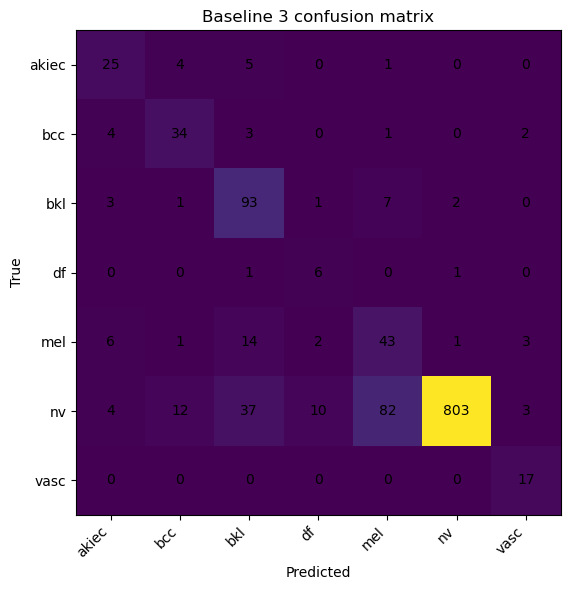

In [28]:
cm_arr = np.array(metrics['confusion_matrix'])
target_names = [CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP.keys())]

plt.figure(figsize=(7, 6))
plt.imshow(cm_arr)
plt.title('Baseline 3 confusion matrix')
plt.xticks(range(len(target_names)), target_names, rotation=45, ha='right')
plt.yticks(range(len(target_names)), target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        plt.text(j, i, str(cm_arr[i, j]), ha='center', va='center')
plt.tight_layout()
plt.show()

## Prediction table for inspection

In [29]:
pred_df = pd.DataFrame(eval_meta)
if 'label' in pred_df.columns:
    pred_df['label'] = pred_df['label'].apply(lambda x: int(x.item()) if torch.is_tensor(x) else int(x))

pred_df['y_true'] = y_true
pred_df['y_pred'] = preds
pred_df['y_true_name'] = [CLASS_NAME_MAP[int(x)] for x in y_true]
pred_df['y_pred_name'] = [CLASS_NAME_MAP[int(x)] for x in preds]
pred_df['correct'] = pred_df['y_true'] == pred_df['y_pred']

for class_id in range(pred_probs.shape[1]):
    pred_df[f"prob_{CLASS_NAME_MAP.get(class_id, str(class_id))}"] = pred_probs[:, class_id]

display(pred_df.head())

,image,label,y_true,y_pred,y_true_name,y_pred_name,correct,prob_akiec,prob_bcc,prob_bkl,prob_df,prob_mel,prob_nv,prob_vasc
0,ISIC_0032343.jpg,2,2,2,bkl,bkl,True,2.935672e-05,4.780627e-09,0.999277,8.373812e-07,0.000575,0.000118,8.209604e-10
1,ISIC_0024698.jpg,5,5,2,nv,bkl,False,2.279900e-08,1.697423e-07,0.816087,5.681886e-10,0.059036,0.124877,9.820396e-10
2,ISIC_0031624.jpg,2,2,2,bkl,bkl,True,2.314409e-06,1.107723e-07,0.999289,5.620630e-09,0.000612,0.000097,4.018784e-09
3,ISIC_0025510.jpg,2,2,2,bkl,bkl,True,3.739163e-08,1.205967e-07,0.978751,2.033279e-04,0.009893,0.011152,1.736267e-08
4,ISIC_0025388.jpg,2,2,2,bkl,bkl,True,3.465259e-08,1.145682e-09,0.998688,1.596804e-10,0.000593,0.000719,5.506949e-10


## Mermaid-ready textual summary

### Actual Baseline 3 pipeline
1. Raw image
2. Resize to 256
3. Center crop to 224
4. Convert to tensor
5. Normalize with ImageNet mean/std
6. Pass through **frozen PanDerm backbone**
7. Use `forward_features()` to obtain embedding
8. Convert embedding to final feature vector
9. L2-normalize feature vector
10. Extract train embeddings
11. Extract val embeddings
12. Extract eval embeddings
13. Optionally standardize embeddings with `StandardScaler`
14. Train a small MLP on train embeddings
15. Use val split for model selection / early stopping
16. Keep best MLP checkpoint
17. Run best MLP on eval embeddings
18. Softmax probabilities
19. Argmax probability -> final predicted class

### Important note
PanDerm is frozen throughout. Backpropagation happens only inside the separate MLP head, not inside the PanDerm backbone.

In [30]:
print('MERMAID SUMMARY')
print('- Raw image')
print('- Transform: resize 256 -> center crop 224 -> tensor -> normalize')
print('- Frozen PanDerm backbone')
print('- Use forward_features() to obtain embedding')
print('- Convert embedding to final feature vector')
print('- L2 normalization')
print('- Extract train / val / eval embeddings')
print('- Optionally standardize embeddings with StandardScaler')
print('- Train small MLP on train embeddings')
print('- Use val split for model selection and early stopping')
print('- Keep best MLP')
print('- Run best MLP on eval embeddings')
print('- Softmax probabilities')
print('- Argmax probability -> final predicted class')
print('- PanDerm backbone is frozen throughout')
print('- Backprop happens only in the separate MLP head')

MERMAID SUMMARY
- Raw image
- Transform: resize 256 -> center crop 224 -> tensor -> normalize
- Frozen PanDerm backbone
- Use forward_features() to obtain embedding
- Convert embedding to final feature vector
- L2 normalization
- Extract train / val / eval embeddings
- Optionally standardize embeddings with StandardScaler
- Train small MLP on train embeddings
- Use val split for model selection and early stopping
- Keep best MLP
- Run best MLP on eval embeddings
- Softmax probabilities
- Argmax probability -> final predicted class
- PanDerm backbone is frozen throughout
- Backprop happens only in the separate MLP head
